In [10]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:14pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

# 1. 데이터 생성
- 남녀 키과 몸무게 데이터를 군집화

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [12]:
random.randint(160, 195)

185

In [17]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60,95), random.randint(160,195)])

In [20]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[::2]])
print('남자 키(y축) :', [male[1] for male in data[::2]])

여자 몸무게(x축) : [66, 40, 52, 47, 47, 70, 44, 61, 48, 60, 52, 60, 43, 40, 43, 57, 69, 64, 63, 43, 63, 53, 47, 44, 53, 54, 51, 55, 44, 55, 63, 45, 60, 46, 68, 54, 45, 64, 54, 44, 51, 63, 62, 42, 57, 59, 56, 59, 64, 51]
여자 키(y축) : [170, 140, 146, 148, 157, 160, 144, 169, 145, 170, 149, 152, 161, 160, 144, 142, 148, 150, 163, 155, 146, 168, 162, 156, 147, 165, 143, 147, 162, 156, 163, 154, 160, 168, 161, 170, 154, 142, 151, 141, 155, 143, 149, 165, 155, 145, 166, 159, 167, 167]
남자 몸무게(x축) : [66, 40, 52, 47, 47, 70, 44, 61, 48, 60, 52, 60, 43, 40, 43, 57, 69, 64, 63, 43, 63, 53, 47, 44, 53, 54, 51, 55, 44, 55, 63, 45, 60, 46, 68, 54, 45, 64, 54, 44, 51, 63, 62, 42, 57, 59, 56, 59, 64, 51]
남자 키(y축) : [170, 140, 146, 148, 157, 160, 144, 169, 145, 170, 149, 152, 161, 160, 144, 142, 148, 150, 163, 155, 146, 168, 162, 156, 147, 165, 143, 147, 162, 156, 163, 154, 160, 168, 161, 170, 154, 142, 151, 141, 155, 143, 149, 165, 155, 145, 166, 159, 167, 167]


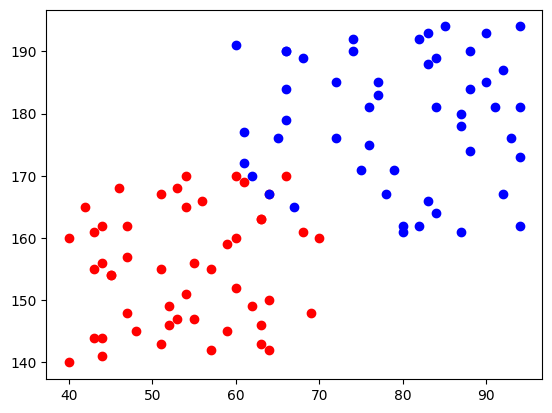

In [24]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')

plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')

plt.show()

# 2. 군집화 로직

In [37]:
# 초기 랜덤 지점 2개
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
    
]
random_points

[[69, 181], [61, 159]]

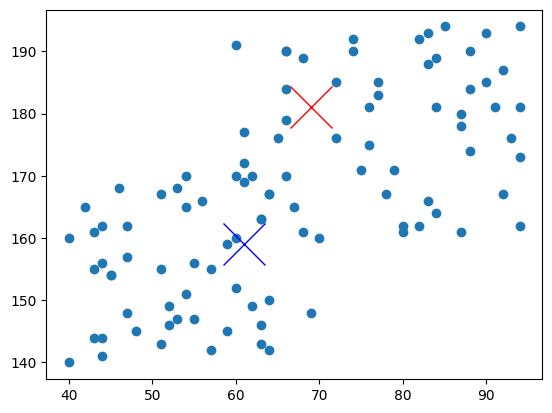

In [38]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='r') # 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='b') # 기준점 1

In [39]:
# 두점 거리를 return하는 함수 점은 [50, 160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2+ (a[1]-b[1])**2)
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [40]:
# randon_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(44, 56)

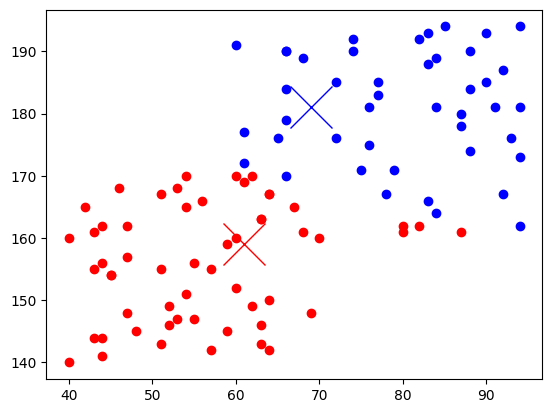

In [41]:
# group0과 group1, random_point[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [43]:
# group0과 group1 중심점으로 기준점을 이용
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group0_meanX = np.mean([d[0] for d in group1])
group0_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX, group1_meanY]
random_poinsts

NameError: name 'group1_meanX' is not defined